In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features:", X.shape)
print("Target:", y.shape)

Features: (569, 30)
Target: (569,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [7]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("ROC AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9649122807017544
Precision : 0.9594594594594594
Recall : 0.9861111111111112
ROC AUC : 0.9953703703703703


In [8]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39  3]
 [ 1 71]]


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



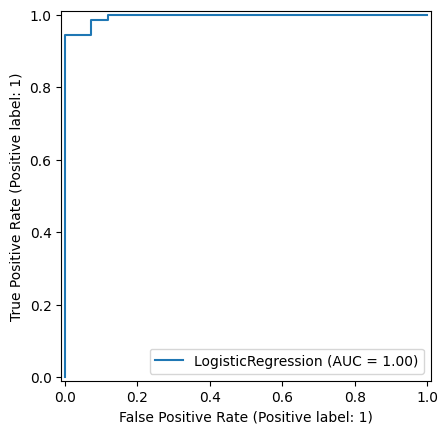

In [10]:
RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.show()

In [11]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="accuracy"
)

print(scores)

print("Average Accuracy:", scores.mean())

[0.95614035 0.96491228 0.93859649 0.97368421 0.92035398]
Average Accuracy: 0.9507374631268437


In [12]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="accuracy"
)

print(scores)

print("Average Accuracy:", scores.mean())

[0.95614035 0.96491228 0.93859649 0.97368421 0.92035398]
Average Accuracy: 0.9507374631268437


In [13]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print(scores)

print("Average Accuracy:", scores.mean())

[0.96491228 0.92105263 0.96491228 0.94736842 0.97345133]
Average Accuracy: 0.9543393882937432


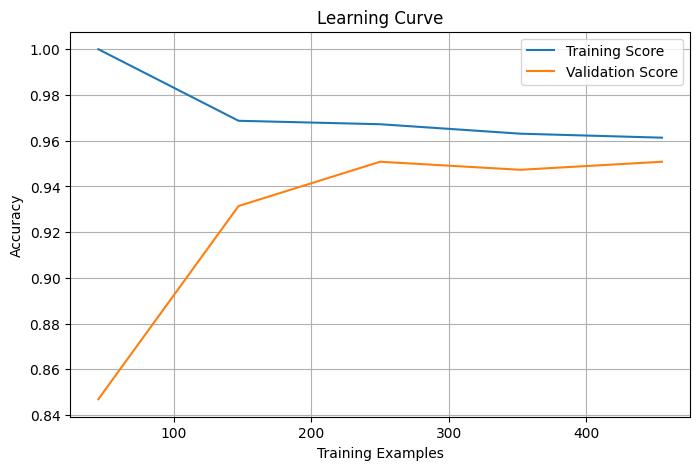

In [14]:
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()